# 13 — Réponses aux 9 questions de synthèse

**Objectif** — répondre, avec un tableau et/ou une figure à l'appui de chaque
réponse, aux neuf questions posées pour ce chantier :

1. Quels motifs et sous-motifs génèrent le plus fort volume, une fois les
   deux sources consolidées et les doublons retirés ?
2. Quelles catégories de réclamation concentrent le plus de tickets ?
3. Quels canaux, et quelles agences (propre à First Copilot), concentrent le
   plus de réclamations ?
4. Quelles catégories, bien que faibles en volume, concentrent les montants
   financiers les plus élevés ?
5. Existe-t-il une tendance temporelle (dégradation, pic) nécessitant une
   investigation ciblée ?
6. Pour chaque problème identifié, quelle action corrective est envisageable
   et quel service en a la charge ?
7. Dans quelle mesure les deux systèmes se recoupent-ils, et que capte le
   First Copilot que Intercom ne capte pas (et réciproquement) ?
8. La reconstruction automatique des sous-motifs à partir du texte libre
   Intercom est-elle fiable, mesurée contre la qualification annotée à la
   main de First Copilot ?
9. La méthode d'analyse est-elle reproductible sur un prochain export de
   chacune des deux sources ?

| | |
|---|---|
| **Entrée** | Système A (notebooks 01-07), First Copilot dédupliqué (notebooks 08-10), validation croisée (notebook 11) |
| **Sorties** | `resultats/tables/13_q*_*.csv` + `resultats/figures/13_q*_*.png` |

Ce notebook ne recalcule rien de nouveau sur le fond : il **réutilise** les
fonctions déjà validées de `src/reclamations/` (mêmes définitions, mêmes
seuils que les notebooks 04, 09, 10, 11, 12) et les réorganise question par
question, avec une figure en plus là où les notebooks sources n'en avaient
pas encore (matrice de confusion, recoupement A/B, exposition par catégorie).
Toute réserve méthodologique déjà posée dans ces notebooks (montants =
ordres de grandeur, rappel des règles plafonné, dédoublonnage = plancher)
reste valable ici et n'est pas répétée à chaque section.

In [1]:
import sys
from pathlib import Path

RACINE = Path.cwd().parent
sys.path.insert(0, str(RACINE / "src"))

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D

from reclamations import chargement, config, consolidation, systeme_b, texte, viz

viz.appliquer_charte()
pd.set_option("display.width", 160)

# --- Système A : périmètre opérationnel complet + classification causale ---
df_a = chargement.typer(chargement.charger_brut())
tickets_a = chargement.perimetre_operationnel(df_a)
messages = chargement.charger_messages_ouverture()
tickets_a = tickets_a.copy()
tickets_a["texte"] = chargement.construire_texte_enrichi(tickets_a, messages)
tickets_a["a_texte"] = texte.a_texte_exploitable(tickets_a["texte"])
tickets_a["famille"] = texte.classer(tickets_a["texte"])

# --- First Copilot : chargement complet, puis dédupliqué (notebook 09) ---
tickets_b_brut = systeme_b.charger_tickets()
categories_b = systeme_b.charger_categories()
groups_b = systeme_b.charger_groups()
champs_b, valeurs_b = systeme_b.charger_champs_personnalises()
sous_motifs_b = systeme_b.sous_motifs(champs_b, valeurs_b)

cles_a = consolidation.cles_a(tickets_a)
cles_b = consolidation.cles_b(tickets_b_brut, champs_b, valeurs_b)
paires = consolidation.apparier(cles_a, cles_b)
tickets_b = consolidation.tickets_b_non_apparies(tickets_b_brut, paires)

print(f"Système A (période opérationnelle)      : {len(tickets_a):,}")
print(f"First Copilot (brut, avant dédoublonnage)    : {len(tickets_b_brut):,}")
print(f"First Copilot (dédupliqué)                   : {len(tickets_b):,}")
print(f"TOTAL CONSOLIDÉ (A + B dédupliqué)        : {len(tickets_a) + len(tickets_b):,}")

/home/gauss/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


/home/gauss/Bureau/Afriland/analyse des reclamation clients/niv/src/reclamations/texte.py:317: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  correspond = texte.str.contains(motif, regex=True, na=False)
/home/gauss/Bureau/Afriland/analyse des reclamation clients/niv/src/reclamations/texte.py:317: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  correspond = texte.str.contains(motif, regex=True, na=False)


/home/gauss/Bureau/Afriland/analyse des reclamation clients/niv/src/reclamations/texte.py:317: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  correspond = texte.str.contains(motif, regex=True, na=False)


/home/gauss/Bureau/Afriland/analyse des reclamation clients/niv/src/reclamations/texte.py:317: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  correspond = texte.str.contains(motif, regex=True, na=False)


/home/gauss/Bureau/Afriland/analyse des reclamation clients/niv/src/reclamations/texte.py:317: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  correspond = texte.str.contains(motif, regex=True, na=False)
/home/gauss/Bureau/Afriland/analyse des reclamation clients/niv/src/reclamations/texte.py:317: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  correspond = texte.str.contains(motif, regex=True, na=False)


Système A (période opérationnelle)      : 18,049
First Copilot (brut, avant dédoublonnage)    : 8,005
First Copilot (dédupliqué)                   : 6,828
TOTAL CONSOLIDÉ (A + B dédupliqué)        : 24,877


## Q1 — Motifs et sous-motifs les plus fréquents, sources consolidées et dédupliquées

C'est la **seule** question où les deux systèmes ne peuvent pas être
additionnés : ils portent deux taxonomies différentes, et le notebook 11 n'a
validé un pont que pour 2 des 6 familles de A (voir Q8). Les deux
répartitions sont donc réunies dans **une même table et une même figure**,
mais gardent leur colonne `systeme` — regroupées pour la lecture, jamais
fusionnées dans un total.

Partout ailleurs (Q2, Q3, Q4), les nomenclatures sont communes aux deux
outils et `tickets_b` est déjà **dédupliqué** des tickets retrouvés dans A
(notebook 09) : la consolidation y est donc une simple somme, sans double
comptage.

In [2]:
base_a = tickets_a[tickets_a["a_texte"]]
familles_a = texte.couverture(base_a["famille"])  # réutilisé en Q6

sm_b = sous_motifs_b.loc[sous_motifs_b.index.isin(tickets_b["id"])]
resume_sm_b = (
    sm_b.groupby(["domaine", "sous_motif"]).size().rename("effectif").reset_index()
    .sort_values("effectif", ascending=False)
)
resume_sm_b["pct"] = (resume_sm_b["effectif"] / len(sm_b) * 100).round(1)

# Un même libellé de sous-motif existe sous plusieurs domaines (« Autre »
# notamment) : le `domaine` fait donc partie de la clé et doit être conservé
# dans la table, sous peine de fusionner deux catégories distinctes.
sm_b_par_motif = (
    resume_sm_b.groupby("sous_motif")["effectif"].sum().sort_values(ascending=False)
)

# Table unique, format long : une ligne par motif, la colonne `systeme` porte
# l'origine. C'est le regroupement le plus loin qu'on puisse aller sans
# prétendre que les deux taxonomies sont la même.
motifs_a_b = pd.concat([
    pd.DataFrame({
        "systeme": "A -- famille causale (règles)",
        "domaine": "",
        "motif": familles_a["libelle"].to_numpy(),
        "effectif": familles_a["effectif"].to_numpy(),
        "pct_de_son_systeme": familles_a["pct"].to_numpy(),
    }),
    pd.DataFrame({
        "systeme": "B -- sous-motif annoté",
        "domaine": resume_sm_b["domaine"].to_numpy(),
        "motif": resume_sm_b["sous_motif"].to_numpy(),
        "effectif": resume_sm_b["effectif"].to_numpy(),
        "pct_de_son_systeme": resume_sm_b["pct"].to_numpy(),
    }),
], ignore_index=True)
chargement.sauver_table(motifs_a_b, "13_q1_motifs_a_b", index=False)

print(f"Base A (textuelle) : {len(base_a):,} tickets  |  Base B (dédupliquée) : {len(sm_b):,} tickets")
print()
print("Système A -- familles causales (règles, plancher -- notebook 04) :")
print(familles_a[["libelle", "effectif", "pct"]].to_string())
print()
print("First Copilot -- 10 sous-motifs annotés les plus fréquents (domaines cumulés) :")
print(sm_b_par_motif.head(10).to_string())

  -> resultats/tables/13_q1_motifs_a_b.csv
Base A (textuelle) : 10,347 tickets  |  Base B (dédupliquée) : 5,457 tickets

Système A -- familles causales (règles, plancher -- notebook 04) :
                                                            libelle  effectif   pct
famille                                                                            
debit_non_credit       Débité sans que le bénéficiaire soit crédité      4294  41.5
non_classe                                Non classé par les règles      3724  36.0
erreur_client     Erreur de saisie du client (mauvais bénéficiaire)       783   7.6
acces_otp                     Accès bloqué / OTP / authentification       701   6.8
debit_injustifie       Débit injustifié, doublé, ou frais contestés       556   5.4
carte                                 Carte bancaire / distributeur       206   2.0
demande_info            Demande d'information (pas une réclamation)        83   0.8

First Copilot -- 10 sous-motifs annotés les plus fréque

  -> resultats/figures/13_q1_motifs_a_b.png


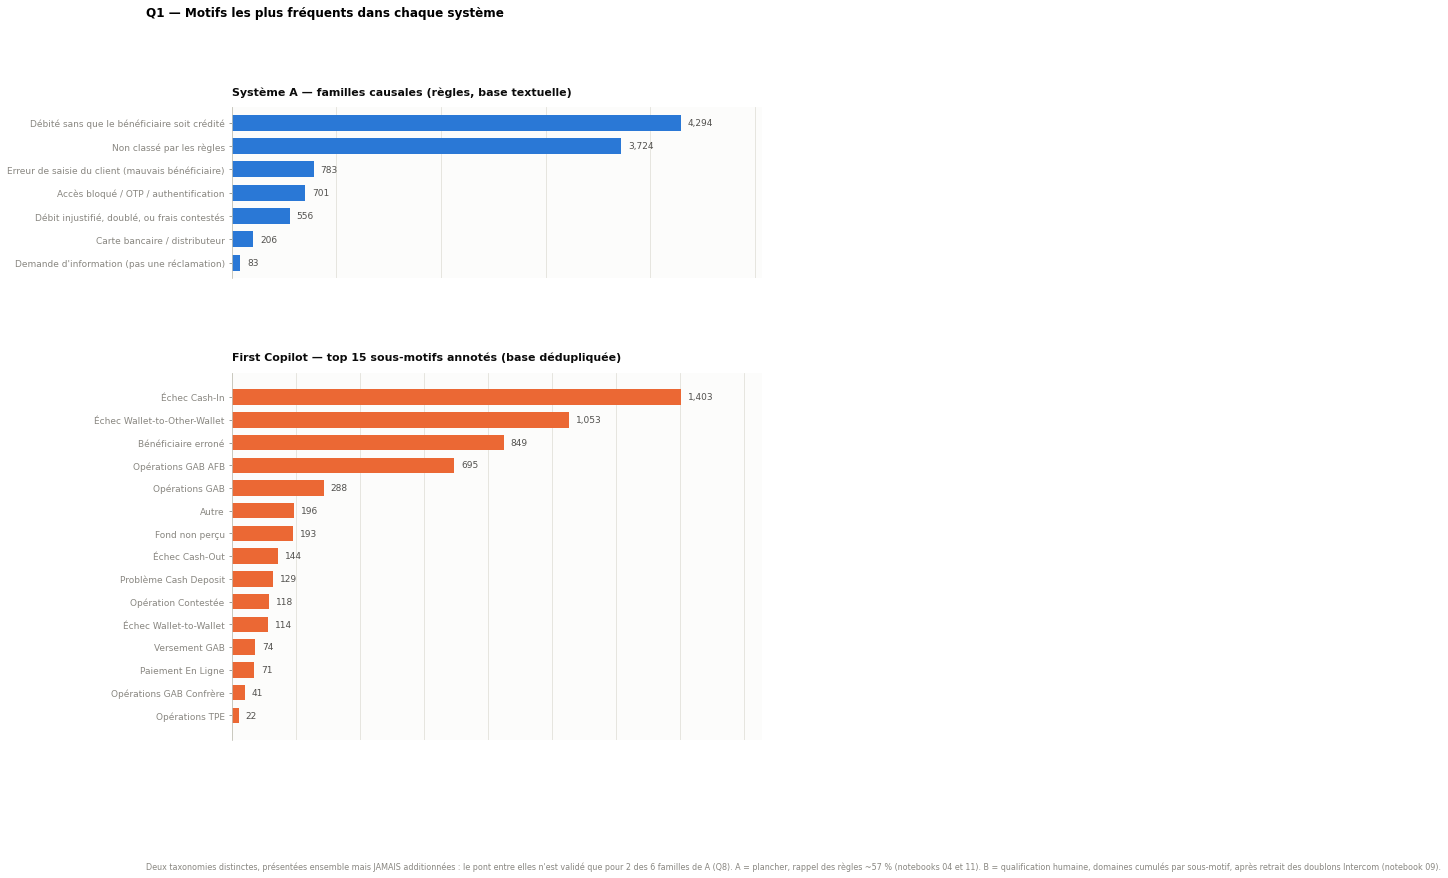

In [3]:
# Une seule figure, deux panneaux : les deux taxonomies se lisent d'un coup
# d'oeil sans qu'aucune addition ne soit suggérée. Hauteurs proportionnelles
# au nombre de barres pour que l'épaisseur des barres reste identique.
#
# Côté B, on trace `sm_b_par_motif` (domaines cumulés) et non `resume_sm_b` :
# ce dernier a une clé (domaine, sous_motif), donc des libellés répétés, qui
# se superposeraient silencieusement sur un axe catégoriel.
serie_a = familles_a.set_index("libelle")["effectif"]
serie_b = sm_b_par_motif.head(15)
assert serie_b.index.is_unique, "libellés de sous-motifs non uniques : les barres se superposeraient"

fig, (ax_a, ax_b) = plt.subplots(
    2, 1, figsize=(9.5, 0.42 * (len(serie_a) + len(serie_b)) + 2.4),
    gridspec_kw={"height_ratios": [len(serie_a), len(serie_b)], "hspace": 0.35},
)
viz.barres_horizontales(serie_a, "Système A — familles causales (règles, base textuelle)",
                        ax=ax_a, couleur=viz.SERIES[0])
viz.barres_horizontales(serie_b, "First Copilot — top 15 sous-motifs annotés (base dédupliquée)",
                        ax=ax_b, couleur=viz.SERIES[1])
fig.suptitle("Q1 — Motifs les plus fréquents dans chaque système", fontsize=12,
             fontweight="bold", x=0.0, ha="left", y=1.0)
viz.annoter_source(
    fig,
    "Deux taxonomies distinctes, présentées ensemble mais JAMAIS additionnées : le pont entre elles n'est validé "
    "que pour 2 des 6 familles de A (Q8). A = plancher, rappel des règles ~57 % (notebooks 04 et 11). "
    "B = qualification humaine, domaines cumulés par sous-motif, après retrait des doublons Intercom (notebook 09).",
)
viz.sauver(fig, "13_q1_motifs_a_b")
plt.show()

## Q2 — Catégories qui concentrent le plus de tickets

`ticket_type_name` (A) et la catégorie de First Copilot (`categories.xlsx`)
partagent la **même nomenclature produit** (SARA, CARTE, MAC, COMPTE,
CREDIT, ACCUEIL, EFIRST, OPERATIONS_INTERNATIONALES…). Comme `tickets_b` est
déjà dédupliqué des tickets retrouvés dans A, les deux volumes s'additionnent
sans double comptage : c'est exactement la base consolidée que demande la
question du protocole.

Le détail par système est conservé en colonnes — la consolidation ne doit
jamais masquer qu'une catégorie peut être portée par un seul des deux outils
(`BENEFICIAIRE ERRONE` n'existe que côté A, `AUTRE` et `SARA_FONCTIONNEL`
que côté B).
**Que recouvre `AUTRE` (First Copilot) ?** C'est une catégorie native de l'outil
— le 17ᵉ choix de `categories.xlsx`, celui que l'agent sélectionne quand
aucune des 16 autres ne convient. Sur les tickets qui y sont rangés, 87 %
n'ont même pas de sous-motif renseigné en plus : ce n'est pas une famille de
problème homogène, c'est le fourre-tout de l'outil. `A` n'a pas d'équivalent
— `ticket_type_name` n'a jamais de valeur manquante dans le périmètre
opérationnel, donc rien n'y échoue par défaut.


In [4]:
cat_a = tickets_a["ticket_type_name"].value_counts()
noms_categories_b = tickets_b["category_id"].map(categories_b.set_index("id")["name"])
cat_b = noms_categories_b.value_counts()

categories_consolide = pd.DataFrame({"systeme_a": cat_a, "systeme_b": cat_b}).fillna(0).astype(int)
categories_consolide["total"] = categories_consolide["systeme_a"] + categories_consolide["systeme_b"]
categories_consolide["pct_total"] = (
    categories_consolide["total"] / categories_consolide["total"].sum() * 100
).round(1)
categories_consolide = categories_consolide.sort_values("total", ascending=False)
categories_consolide.index.name = "categorie"
chargement.sauver_table(categories_consolide, "13_q2_categories_a_b")

n_total = int(categories_consolide["total"].sum())
print(f"Base consolidée (A + B dédupliqué) : {n_total:,} tickets "
      f"= {len(tickets_a):,} (A) + {len(tickets_b):,} (B dédupliqué)")
print()
print(categories_consolide.to_string())

  -> resultats/tables/13_q2_categories_a_b.csv
Base consolidée (A + B dédupliqué) : 24,877 tickets = 18,049 (A) + 6,828 (B dédupliqué)

                                 systeme_a  systeme_b  total  pct_total
categorie                                                              
SARA                                 10673       4014  14687       59.0
COMPTE                                4917        343   5260       21.1
CARTE                                  681       1368   2049        8.2
MAC                                    159        573    732        2.9
BENEFICIAIRE ERRONE                    572          0    572        2.3
CREDIT                                 387         50    437        1.8
ACCUEIL                                278         26    304        1.2
AUTRE                                    0        285    285        1.1
OPERATIONS_INTERNATIONALES             172         16    188        0.8
EFIRST                                  86         23    109        0.4


  -> resultats/figures/13_q2_categories_a_b.png


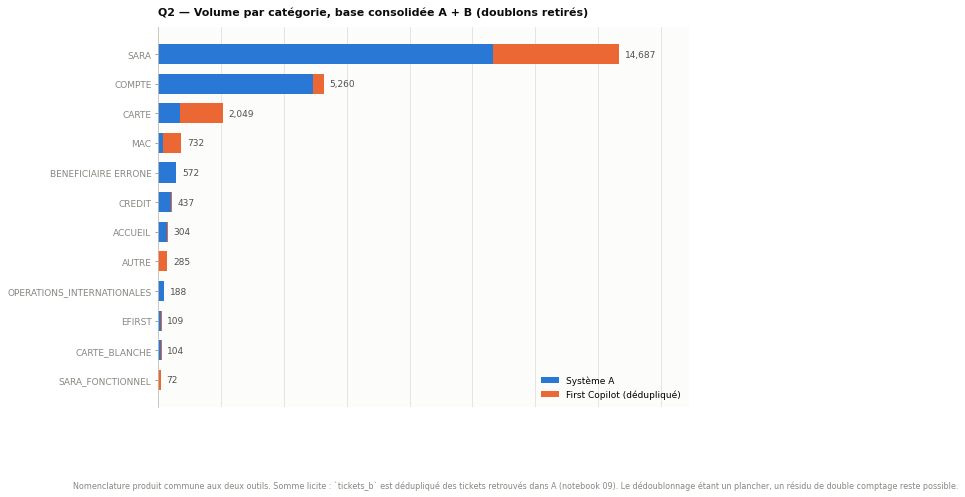

In [5]:
# Barres groupées : le total consolidé se lit par la longueur cumulée, la
# contribution de chaque outil par la couleur. Empilé plutôt que côte à côte
# parce que la question porte sur le volume TOTAL par catégorie.
top_cat = categories_consolide.head(12).iloc[::-1]
fig, ax = plt.subplots(figsize=(9.5, 0.45 * len(top_cat) + 1.6))
y = range(len(top_cat))
ax.barh(list(y), top_cat["systeme_a"], height=0.68, color=viz.SERIES[0], label="Système A")
ax.barh(list(y), top_cat["systeme_b"], height=0.68, left=top_cat["systeme_a"],
        color=viz.SERIES[1], label="First Copilot (dédupliqué)")
for i, (_, ligne) in enumerate(top_cat.iterrows()):
    ax.text(ligne["total"] + top_cat["total"].max() * 0.012, i, f"{int(ligne['total']):,}",
            va="center", fontsize=9, color=viz.ENCRE["secondaire"])
ax.set_yticks(list(y))
ax.set_yticklabels(top_cat.index, fontsize=9)
ax.set_xlim(0, top_cat["total"].max() * 1.15)
ax.tick_params(axis="x", labelbottom=False, length=0)
ax.spines["bottom"].set_visible(False)
ax.grid(axis="y", visible=False)
ax.set_title("Q2 — Volume par catégorie, base consolidée A + B (doublons retirés)")
ax.legend(frameon=False, fontsize=9, loc="lower right")
viz.annoter_source(
    fig,
    "Nomenclature produit commune aux deux outils. Somme licite : `tickets_b` est dédupliqué des tickets "
    "retrouvés dans A (notebook 09). Le dédoublonnage étant un plancher, un résidu de double comptage reste possible.",
)
viz.sauver(fig, "13_q2_categories_a_b")
plt.show()

## Q3 — Canaux, et agences (propre à First Copilot)

Attention au piège : `channel` (A) et `canal` (B) **ne sont pas la même
variable**. `canal` (B) est le canal d'entrée au sens large (agence,
courrier, appel, INTERCOM ressaisi…), tandis que `channel` (A) est le
sous-canal *digital à l'intérieur d'Intercom* (android, ios, whatsapp…).
Les mettre sur le même axe serait une erreur de catégorie.

Le regroupement correct est donc **hiérarchique** : une vue consolidée du
canal d'entrée, dans laquelle la part Intercom est ensuite éclatée en ses
sous-canaux digitaux. C'est la lecture que ni A ni B ne donne seul.

L'agence, elle, n'existe que côté B — c'est une dimension que A ne peut, par
construction, jamais apporter, et elle reste donc présentée seule.
**Que recouvre `AUTRE` (canal, First Copilot) ?** C'est, de la même façon, la
8ᵉ valeur du menu déroulant `canal` que l'agent choisit à la saisie quand
l'entrée ne correspond à aucun des 7 canaux nommés (agence, courrier, appel,
collègue, mail, whatsapp, INTERCOM ressaisi). Aucune sous-qualification
n'existe derrière cette valeur dans l'export — impossible de savoir, par
exemple, si c'est un réseau social non listé ou un mode de saisie interne.


In [6]:
# Sous-canaux digitaux Intercom, regroupés en 3 canaux lisibles pour un lecteur
# métier -- android/ios sont deux OS de la même appli SARA, pas deux canaux
# distincts (config.REGROUPEMENT_CANAL_DIGITAL, chargement.regrouper_canal_digital).
canal_a = chargement.regrouper_canal_digital(tickets_a["channel"]).value_counts()
canal_b = tickets_b["canal"].value_counts()            # canal d'entrée, B dédupliqué

# Niveau 1 -- canal d'entrée consolidé. Les tickets de A sont tous, par
# construction, entrés par Intercom : ils rejoignent la ligne INTERCOM de B.
canaux_consolide = canal_b.rename("systeme_b").to_frame()
canaux_consolide["systeme_a"] = 0
canaux_consolide.loc["INTERCOM", "systeme_a"] = len(tickets_a)
canaux_consolide["total"] = canaux_consolide["systeme_a"] + canaux_consolide["systeme_b"]
canaux_consolide["pct_total"] = (
    canaux_consolide["total"] / canaux_consolide["total"].sum() * 100
).round(1)
canaux_consolide = canaux_consolide[["systeme_a", "systeme_b", "total", "pct_total"]]
canaux_consolide = canaux_consolide.sort_values("total", ascending=False)
canaux_consolide.index.name = "canal_entree"
chargement.sauver_table(canaux_consolide, "13_q3_canaux_a_b")

# Niveau 2 -- éclatement de la part Intercom (disponible côté A uniquement).
detail_intercom = canal_a.rename("effectif").to_frame()
detail_intercom["pct_intercom_a"] = (detail_intercom["effectif"] / len(tickets_a) * 100).round(1)
detail_intercom.index.name = "sous_canal_digital"
chargement.sauver_table(detail_intercom, "13_q3_sous_canaux_intercom_a")

noms_groupes = tickets_b["source_group_id"].map(groups_b.set_index("id")["group_name"])
est_agence = noms_groupes.str.startswith("FIRST_BANK_", na=False)
agences = noms_groupes[est_agence].value_counts().rename("effectif").to_frame().head(15)
agences["pct_des_tickets_agence"] = (agences["effectif"] / est_agence.sum() * 100).round(1)
chargement.sauver_table(agences, "13_q3_top_agences")

print("Canal d'entrée consolidé (A + B dédupliqué) :")
print(canaux_consolide.to_string())
print()
print("Éclatement de la part Intercom, sous-canaux digitaux (Système A seul) :")
print(detail_intercom.to_string())
print()
print(f"Top 15 agences, sur {int(est_agence.sum()):,} tickets B rattachés à une agence :")
print(agences.to_string())

  -> resultats/tables/13_q3_canaux_a_b.csv
  -> resultats/tables/13_q3_sous_canaux_intercom_a.csv
  -> resultats/tables/13_q3_top_agences.csv
Canal d'entrée consolidé (A + B dédupliqué) :
              systeme_a  systeme_b  total  pct_total
canal_entree                                        
INTERCOM          18049       2293  20342       81.8
EN_AGENCE             0       1970   1970        7.9
COURRIER              0        996    996        4.0
APPEL                 0        470    470        1.9
COLLEGUE              0        322    322        1.3
MAIL                  0        287    287        1.2
WHATSAPP              0        243    243        1.0
AUTRE                 0        242    242        1.0

Éclatement de la part Intercom, sous-canaux digitaux (Système A seul) :
                    effectif  pct_intercom_a
sous_canal_digital                          
SARA                   15561            86.2
WhatsApp                2297            12.7
Facebook                 181 

  -> resultats/figures/13_q3_canaux_a_b.png


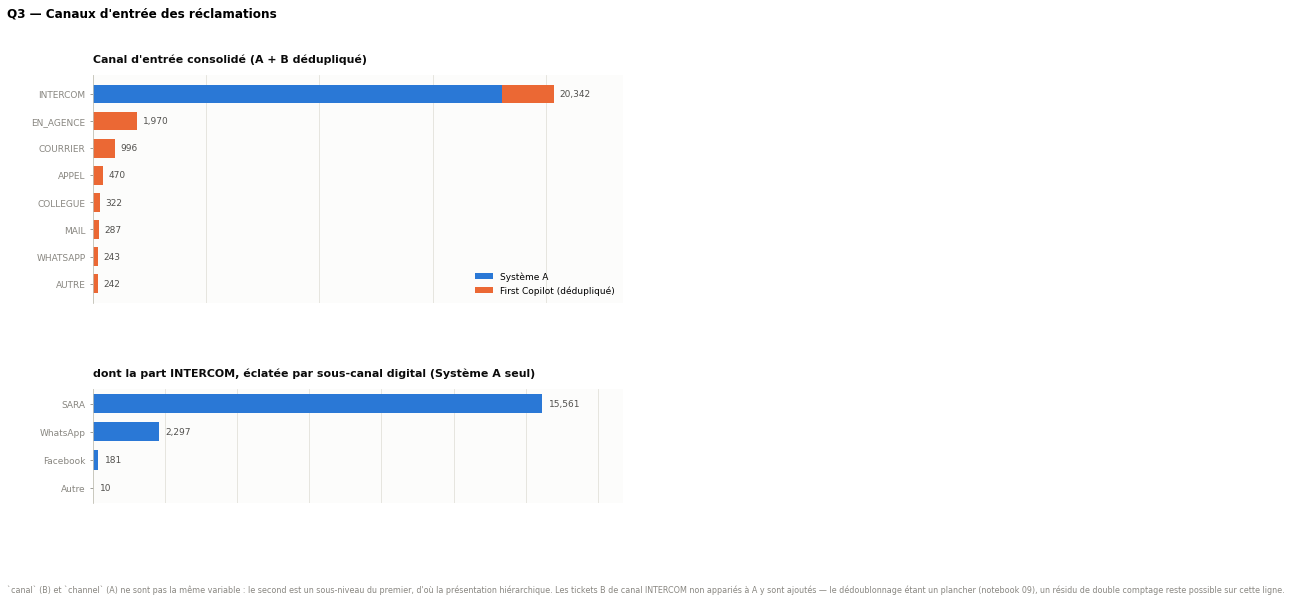

  -> resultats/figures/13_q3_top_agences.png


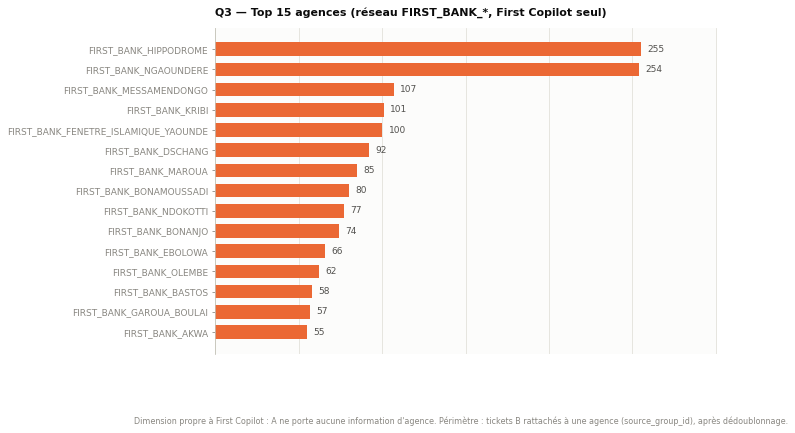

In [7]:
# Deux panneaux emboîtés : le canal d'entrée consolidé, puis le détail du
# seul canal que A permet d'éclater. La hiérarchie est explicite, aucune
# variable n'est mise à plat avec une autre qui n'a pas le même sens.
fig, (ax_h, ax_d) = plt.subplots(
    2, 1, figsize=(9.5, 0.44 * (len(canaux_consolide) + len(detail_intercom)) + 2.6),
    gridspec_kw={"height_ratios": [len(canaux_consolide), len(detail_intercom)], "hspace": 0.5},
)

ordre = canaux_consolide.iloc[::-1]
y = range(len(ordre))
ax_h.barh(list(y), ordre["systeme_a"], height=0.68, color=viz.SERIES[0], label="Système A")
ax_h.barh(list(y), ordre["systeme_b"], height=0.68, left=ordre["systeme_a"],
          color=viz.SERIES[1], label="First Copilot (dédupliqué)")
for i, (_, ligne) in enumerate(ordre.iterrows()):
    ax_h.text(ligne["total"] + ordre["total"].max() * 0.012, i, f"{int(ligne['total']):,}",
              va="center", fontsize=9, color=viz.ENCRE["secondaire"])
ax_h.set_yticks(list(y))
ax_h.set_yticklabels(ordre.index, fontsize=9)
ax_h.set_xlim(0, ordre["total"].max() * 1.15)
ax_h.tick_params(axis="x", labelbottom=False, length=0)
ax_h.spines["bottom"].set_visible(False)
ax_h.grid(axis="y", visible=False)
ax_h.set_title("Canal d'entrée consolidé (A + B dédupliqué)")
ax_h.legend(frameon=False, fontsize=9, loc="lower right")

viz.barres_horizontales(
    detail_intercom["effectif"],
    "dont la part INTERCOM, éclatée par sous-canal digital (Système A seul)",
    ax=ax_d, couleur=viz.SERIES[0],
)
fig.suptitle("Q3 — Canaux d'entrée des réclamations", fontsize=12, fontweight="bold",
             x=0.0, ha="left", y=1.0)
viz.annoter_source(
    fig,
    "`canal` (B) et `channel` (A) ne sont pas la même variable : le second est un sous-niveau du premier, d'où la "
    "présentation hiérarchique. Les tickets B de canal INTERCOM non appariés à A y sont ajoutés — le dédoublonnage "
    "étant un plancher (notebook 09), un résidu de double comptage reste possible sur cette ligne.",
)
viz.sauver(fig, "13_q3_canaux_a_b")
plt.show()

fig, ax = plt.subplots(figsize=(9, max(3.6, 0.4 * len(agences))))
viz.barres_horizontales(agences["effectif"], "Q3 — Top 15 agences (réseau FIRST_BANK_*, First Copilot seul)",
                        ax=ax, couleur=viz.SERIES[1])
viz.annoter_source(fig, "Dimension propre à First Copilot : A ne porte aucune information d'agence. "
                        "Périmètre : tickets B rattachés à une agence (source_group_id), après dédoublonnage.")
viz.sauver(fig, "13_q3_top_agences")
plt.show()

## Q4 — Catégories à faible volume mais forte exposition financière

Montants **plausibles uniquement** (`chargement.montants_plausibles` /
`systeme_b.montants_plausibles` : strictement positifs, sous le plafond de
vraisemblance) — ordre de grandeur, jamais un chiffre officiel (protocole
§ 8.4). On lit la **médiane**, insensible aux valeurs extrêmes, comme au
notebook 04 § 7.

La nomenclature étant commune (Q2), les deux expositions sont réunies dans
une table unique. Les **totaux** s'additionnent (montants portés par des
tickets distincts, B étant dédupliqué) ; les **médianes**, non — une médiane
de médianes n'a pas de sens, les deux colonnes restent donc côte à côte.
C'est aussi ici que se voit le mieux l'apport de B, dont le champ montant est
nettement mieux renseigné que celui d'Intercom (protocole, phase 4) : 1 267
tickets CARTE valorisés côté B contre 87 côté A.
**Pourquoi pas une médiane de médianes, concrètement ?** Parce que la
médiane n'est pas une opération qui se recompose : contrairement à une
somme (`total_a + total_b` compte bien chaque ticket une fois), la médiane
d'un groupe dépend de sa taille, et moyenner deux médianes traite à égalité
une catégorie de 2 tickets et une de 8 254 (SARA A). Ici, `RECLAMATIONS_
DIRECTION_GENERALE` (2 tickets, 367 k) pèserait alors autant que `SARA`
(8 254 tickets, 41,7 k) dans une médiane de médianes — un artefact de
petit échantillon présenté comme un signal. D'où le choix : deux colonnes
côte à côte, chacune lisible sur son propre effectif, jamais moyennées
entre elles.


In [8]:
mt_a_cat = chargement.montants_plausibles(tickets_a)
expo_cat_a = mt_a_cat.groupby("ticket_type_name")["montant"].agg(
    tickets="count", mediane="median", total="sum"
).sort_values("mediane", ascending=False)

mt_b = systeme_b.montants_plausibles(champs_b, valeurs_b)
mt_b_dedup = mt_b.loc[mt_b.index.isin(tickets_b["id"])]
cat_par_id = tickets_b.set_index("id")["category_id"].map(categories_b.set_index("id")["name"])
expo_cat_b = pd.DataFrame(
    {"montant": mt_b_dedup, "categorie": cat_par_id.reindex(mt_b_dedup.index)}
).groupby("categorie")["montant"].agg(
    tickets="count", mediane="median", total="sum"
).sort_values("mediane", ascending=False)

exposition = pd.DataFrame({
    "tickets_a": expo_cat_a["tickets"], "mediane_a": expo_cat_a["mediane"], "total_a": expo_cat_a["total"],
    "tickets_b": expo_cat_b["tickets"], "mediane_b": expo_cat_b["mediane"], "total_b": expo_cat_b["total"],
})
exposition[["tickets_a", "tickets_b"]] = exposition[["tickets_a", "tickets_b"]].fillna(0).astype(int)
exposition["tickets_total"] = exposition["tickets_a"] + exposition["tickets_b"]
exposition["total_consolide"] = exposition[["total_a", "total_b"]].fillna(0).sum(axis=1)
exposition = exposition.sort_values("total_consolide", ascending=False).round(0)
exposition.index.name = "categorie"
chargement.sauver_table(exposition, "13_q4_exposition_a_b")

print("Exposition financière par catégorie, les deux systèmes réunis "
      "(triée par montant total consolidé) :")
print(exposition.to_string())
print()
print(f"Exposition totale consolidée : {exposition['total_consolide'].sum():,.0f} XAF "
      f"sur {int(exposition['tickets_total'].sum()):,} tickets valorisés")

  -> resultats/tables/13_q4_exposition_a_b.csv
Exposition financière par catégorie, les deux systèmes réunis (triée par montant total consolidé) :
                                 tickets_a  mediane_a      total_a  tickets_b  mediane_b      total_b  tickets_total  total_consolide
categorie                                                                                                                            
SARA                                  4343    41500.0  503289605.0       3911    50000.0  609233473.0           8254     1.112523e+09
COMPTE                                2415    51000.0  462092608.0        303   225000.0  144159940.0           2718     6.062525e+08
CARTE                                   87   115000.0   17475805.0       1267   150000.0  319717383.0           1354     3.371932e+08
CREDIT                                  61   600000.0   92019674.0         38  1040000.0  115036381.0             99     2.070561e+08
MAC                                      0       

  -> resultats/figures/13_q4_volume_vs_montant.png


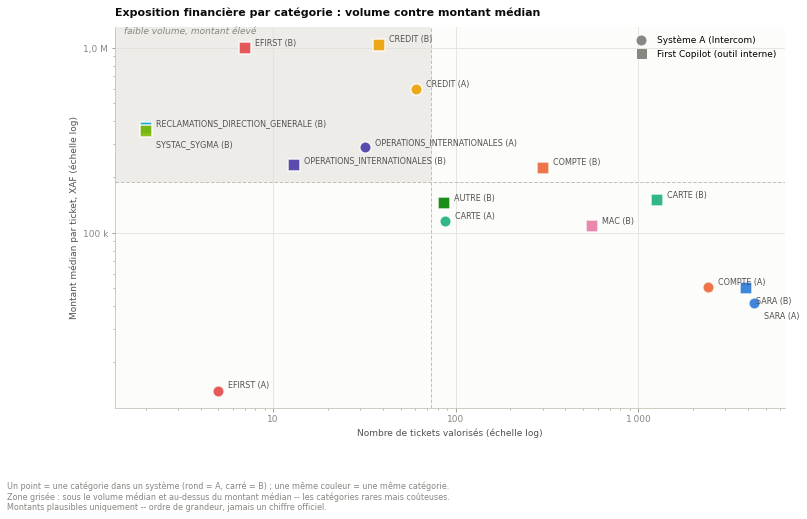

In [9]:
# Une couleur par catégorie -- la même dans les deux systèmes -- et une forme par
# système : la même catégorie se retrouve d'un système à l'autre sans passer par
# une légende. L'identité de chaque point est portée par son étiquette écrite, la
# couleur ne fait que séparer les points voisins (cf. viz.SERIES_ETENDUE).
categories = list(exposition.index)
couleur_cat = dict(zip(categories, viz.SERIES_ETENDUE))

points = []
for systeme, col_n, col_m, marqueur in (
    ("A", "tickets_a", "mediane_a", "o"),
    ("B", "tickets_b", "mediane_b", "s"),
):
    for cat in categories:
        n, m = exposition.loc[cat, col_n], exposition.loc[cat, col_m]
        if n > 0 and pd.notna(m):
            points.append((cat, systeme, float(n), float(m), marqueur))

fig, ax = plt.subplots(figsize=(12, 7))
for cat, systeme, n, m, marqueur in points:
    ax.scatter(
        n, m, s=130, marker=marqueur, color=couleur_cat[cat], alpha=0.9,
        edgecolor=viz.ENCRE["surface"], linewidth=1.5, zorder=3,
    )

# Échelles logarithmiques sur les deux axes : les volumes vont de 2 à 4 348
# tickets et les montants de 14 000 à 1 040 000 XAF. En échelle linéaire, huit
# catégories sur dix se tassent contre l'axe et deviennent illisibles une fois
# étiquetées -- c'était le défaut de la version précédente de cette figure.
ax.set_xscale("log")
ax.set_yscale("log")
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda v, _: f"{v:,.0f}".replace(",", "\u202f"))
)
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(
        lambda v, _: f"{v / 1e6:.1f} M".replace(".", ",") if v >= 1e6 else f"{v / 1e3:.0f} k"
    )
)

# La réponse à Q4 se lit dans le quadrant haut-gauche : peu de tickets, montants
# élevés. Les deux médianes qui le délimitent sont tracées, sinon le lecteur ne
# voit pas où commence « faible volume ».
seuil_n = float(np.median([p[2] for p in points]))
seuil_m = float(np.median([p[3] for p in points]))
ax.axvline(seuil_n, color=viz.ENCRE["axe"], linestyle="--", linewidth=1, zorder=1)
ax.axhline(seuil_m, color=viz.ENCRE["axe"], linestyle="--", linewidth=1, zorder=1)
x_min, x_max = ax.get_xlim()
y_min, y_max = ax.get_ylim()
ax.add_patch(
    plt.Rectangle(
        (x_min, seuil_m), seuil_n - x_min, y_max - seuil_m,
        facecolor=viz.ENCRE["grille"], alpha=0.55, linewidth=0, zorder=0,
    )
)
ax.text(
    x_min * 1.12, y_max * 0.93, "faible volume, montant élevé",
    fontsize=9, style="italic", color=viz.ENCRE["muet"], zorder=2,
)
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)

ax.set_xlabel("Nombre de tickets valorisés (échelle log)")
ax.set_ylabel("Montant médian par ticket, XAF (échelle log)")
ax.set_title("Exposition financière par catégorie : volume contre montant médian")
ax.legend(
    handles=[
        Line2D([], [], marker="o", linestyle="none", color=viz.ENCRE["muet"],
               markersize=9, label="Système A (Intercom)"),
        Line2D([], [], marker="s", linestyle="none", color=viz.ENCRE["muet"],
               markersize=9, label="First Copilot (outil interne)"),
    ],
    frameon=False, fontsize=9, loc="upper right",
)


# Placement des étiquettes : toutes les catégories sont nommées. Chaque position
# candidate est essayée dans l'ordre jusqu'à en trouver une qui ne chevauche
# aucune étiquette déjà posée -- les noms sont longs (OPERATIONS_INTERNATIONALES,
# RECLAMATIONS_DIRECTION_GENERALE) et se superposaient sans ce placement.
def _boite(x_ecran, y_ecran, dx, dy, largeur, hauteur):
    gauche = x_ecran + dx if dx >= 0 else x_ecran + dx - largeur
    return (gauche, y_ecran + dy - hauteur / 2, gauche + largeur, y_ecran + dy + hauteur / 2)


def _chevauche(a, b):
    return not (a[2] < b[0] or b[2] < a[0] or a[3] < b[1] or b[3] < a[1])


CANDIDATS = (
    (10, 5), (10, -13), (-10, 5), (-10, -13), (10, 20), (10, -28),
    (-10, 20), (-10, -28), (10, 35), (-10, 35), (10, -43), (-10, -43),
)

fig.canvas.draw()
occupees = []
for cat, systeme, n, m, _marqueur in sorted(points, key=lambda p: -p[3]):
    etiquette = f"{cat} ({systeme})"
    largeur, hauteur = 6.1 * len(etiquette), 12.0
    x_ecran, y_ecran = ax.transData.transform((n, m))
    for dx, dy in CANDIDATS:
        boite = _boite(x_ecran, y_ecran, dx, dy, largeur, hauteur)
        if not any(_chevauche(boite, prise) for prise in occupees):
            break
    occupees.append(boite)
    ax.annotate(
        etiquette, (n, m), xytext=(dx, dy), textcoords="offset points",
        ha="left" if dx >= 0 else "right", va="center", fontsize=8,
        color=viz.ENCRE["secondaire"], zorder=4,
    )

viz.annoter_source(
    fig,
    "Un point = une catégorie dans un système (rond = A, carré = B) ; une même couleur = une même catégorie.\n"
    "Zone grisée : sous le volume médian et au-dessus du montant médian -- les catégories rares mais coûteuses.\n"
    "Montants plausibles uniquement -- ordre de grandeur, jamais un chiffre officiel.",
)
viz.sauver(fig, "13_q4_volume_vs_montant")
plt.show()


## Q5 — Tendance temporelle

La rupture de collecte du 13/03/2026 (notebook 02) reste le seul événement
déjà daté avec certitude : pic de volume et effondrement simultané de la
complétude des champs, retour à la normale mi-mai. On y ajoute ici le volume
mensuel de First Copilot sur la même échelle de temps, jamais fait jusqu'ici,
pour voir s'il porte la même signature ou une tendance propre.

Un seul graphique, barres groupées mois par mois plutôt que deux panneaux
empilés : les deux séries sont dans la **même unité** (tickets/mois), rien
n'interdit de les lire sur un seul axe -- contrairement à Q3 du notebook 02
(volume vs % de complétude), où deux unités différentes imposaient deux
panneaux. Le dernier mois (export partiel) est affiché en transparence
réduite pour ne pas être lu comme les autres.

**Tendance propre à Intercom** -- une moyenne mobile sur 3 mois y est
superposée pour répondre directement à la question : le volume, hors de
l'épisode de rupture, monte-t-il, descend-il, ou est-il stable ?


  -> resultats/figures/13_q5_volume_mensuel_a_b.png


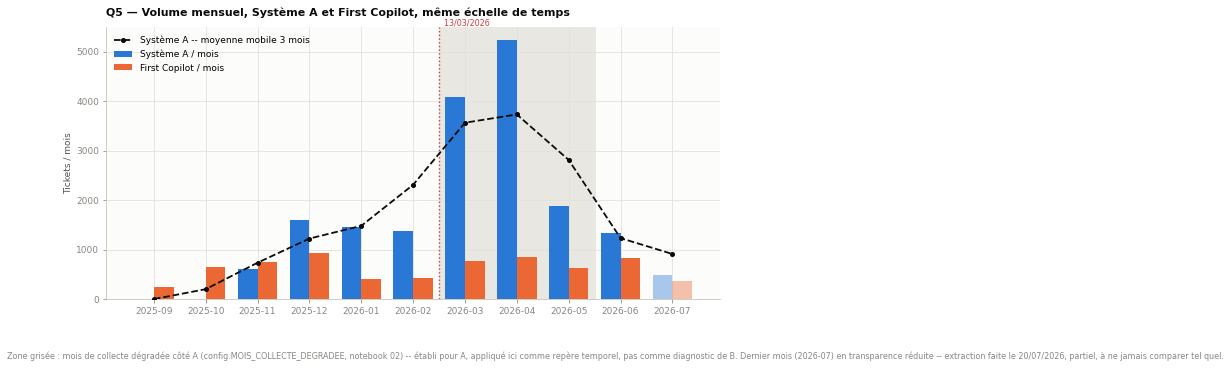

In [10]:
mensuel_a = tickets_a.set_index("date_creation")["id"].resample("MS").size()
mensuel_b = tickets_b.set_index("created_at")["id"].resample("MS").size()

toutes_dates = mensuel_a.index.union(mensuel_b.index)
mensuel_a = mensuel_a.reindex(toutes_dates, fill_value=0)
mensuel_b = mensuel_b.reindex(toutes_dates, fill_value=0)

perimetre_mois = toutes_dates.to_period("M")
est_partiel = perimetre_mois == config.MOIS_PARTIEL
mois_degrades = set(config.MOIS_COLLECTE_DEGRADEE)
est_degrade = perimetre_mois.isin(mois_degrades)
labels = perimetre_mois.astype(str)

# Tendance propre à Intercom : moyenne mobile 3 mois, tous mois confondus --
# le volume brut d'un mois dégradé reste un vrai décompte de tickets (seuls
# les CHAMPS du ticket ont disparu, pas le ticket lui-même), donc la lisser
# dans la tendance est légitime ; la zone grisée rappelle où l'interpréter
# avec prudence.
tendance_a = mensuel_a.rolling(3, min_periods=2, center=True).mean()

x = np.arange(len(toutes_dates))
largeur = 0.38

fig, ax = plt.subplots(figsize=(11, 5))
for xi in x:
    if est_degrade[xi]:
        ax.axvspan(xi - 0.5, xi + 0.5, color=viz.ZONE_INVALIDE, zorder=0)
barres_a = ax.bar(x - largeur / 2, mensuel_a.to_numpy(), width=largeur, color=viz.SERIES[0],
                   zorder=3, label="Système A / mois")
barres_b = ax.bar(x + largeur / 2, mensuel_b.to_numpy(), width=largeur, color=viz.SERIES[1],
                   zorder=3, label="First Copilot / mois")
# alpha réduit pour le seul mois partiel -- bar() n'accepte qu'un alpha scalaire
# par appel, donc appliqué barre par barre après coup plutôt qu'en argument.
for xi in x[est_partiel]:
    barres_a[xi].set_alpha(0.4)
    barres_b[xi].set_alpha(0.4)
ax.plot(x, tendance_a.to_numpy(), color=viz.ENCRE["primaire"], linewidth=1.8,
        linestyle="--", marker="o", markersize=4, zorder=4,
        label="Système A -- moyenne mobile 3 mois")

# Frontière de la rupture : entre le dernier mois pré-rupture et le premier
# mois dégradé -- un axe catégoriel n'a pas de position "13 du mois", la
# frontière entre barres est la lecture la plus honnête.
idx_rupture = next(i for i in x if est_degrade[i])
ax.axvline(idx_rupture - 0.5, color=viz.STATUT["critique"], linewidth=1.4, linestyle=":")
ax.text(idx_rupture - 0.5, ax.get_ylim()[1] if ax.get_ylim()[1] else 1, "  13/03/2026",
        color=viz.STATUT["critique"], fontsize=8, va="bottom")

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9, rotation=0)
ax.set_ylabel("Tickets / mois")
ax.set_title("Q5 — Volume mensuel, Système A et First Copilot, même échelle de temps")
ax.legend(frameon=False, fontsize=9, loc="upper left")
viz.annoter_source(
    fig,
    "Zone grisée : mois de collecte dégradée côté A (config.MOIS_COLLECTE_DEGRADEE, notebook 02) -- établi pour A, "
    "appliqué ici comme repère temporel, pas comme diagnostic de B. Dernier mois "
    f"({config.MOIS_PARTIEL}) en transparence réduite -- extraction faite le 20/07/2026, partiel, à ne jamais comparer tel quel.",
)
viz.sauver(fig, "13_q5_volume_mensuel_a_b")
plt.show()


In [11]:
# Mois complets uniquement (le dernier mois de l'export est partiel, config.MOIS_PARTIEL)
complets_a = mensuel_a[perimetre_mois != config.MOIS_PARTIEL]
complets_b = mensuel_b[perimetre_mois != config.MOIS_PARTIEL]
perimetre_complets = perimetre_mois[perimetre_mois != config.MOIS_PARTIEL]

tendance = pd.DataFrame({"Système A": complets_a, "First Copilot": complets_b})
tendance.index = perimetre_complets.astype(str)
chargement.sauver_table(tendance, "13_q5_volume_mensuel_complet")
print("Volume mensuel, mois complets uniquement :")
print(tendance)
print()

# Trois fenêtres, définies sur le repère A (config.MOIS_COLLECTE_DEGRADEE) :
# stable avant, dégradée, stable après. Un seul mois est disponible dans la
# fenêtre "après" (juin) -- suffisant pour situer le retour à la normale,
# pas pour affirmer une tendance durable.
mois_degrades = set(config.MOIS_COLLECTE_DEGRADEE)
est_degrade_c = perimetre_complets.isin(mois_degrades)
est_apres_c = perimetre_complets > max(mois_degrades)

# Côté A, "avant rupture" ne doit compter que les mois où A existe déjà --
# sept./oct. 2025 sont à 0 par construction (avant config.DEBUT_PERIODE_
# OPERATIONNELLE, notebook 02), pas par une vraie baisse de volume ; les
# laisser dans la moyenne "avant" la déflate artificiellement. B, lui, a une
# vraie histoire dès septembre : pas de troncature à lui appliquer.
est_avant_a = ~est_degrade_c & ~est_apres_c & (perimetre_complets >= config.DEBUT_PERIODE_OPERATIONNELLE.to_period("M"))
avant_a, degrade_a, apres_a = complets_a[est_avant_a], complets_a[est_degrade_c], complets_a[est_apres_c]
avant_b, degrade_b, apres_b = (
    complets_b[~est_degrade_c & ~est_apres_c], complets_b[est_degrade_c], complets_b[est_apres_c]
)

print("Tendance propre à Intercom (Système A) :")
print(f"  avant rupture   ({len(avant_a)} mois) : {avant_a.mean():.0f} tickets/mois")
print(f"  pendant rupture ({len(degrade_a)} mois) : {degrade_a.mean():.0f} tickets/mois "
      f"({degrade_a.mean() / avant_a.mean() - 1:+.0%} vs avant)")
print(f"  après rupture   ({len(apres_a)} mois)  : {apres_a.mean():.0f} tickets/mois "
      f"({apres_a.mean() / avant_a.mean() - 1:+.0%} vs avant)")
print(
    "  -> le volume post-rupture revient près de son niveau d'avant ; un seul mois "
    "propre est disponible après le 13/05, ce n'est pas suffisant pour conclure à "
    "une tendance durable -- à reconfirmer sur le prochain export."
)
print()
print("Pour comparaison, First Copilot sur les mêmes fenêtres (repère établi pour A, "
      "pas pour B -- lecture indicative, pas un diagnostic) :")
print(f"  avant rupture   ({len(avant_b)} mois) : {avant_b.mean():.0f} tickets/mois")
print(f"  pendant rupture ({len(degrade_b)} mois) : {degrade_b.mean():.0f} tickets/mois "
      f"({degrade_b.mean() / avant_b.mean() - 1:+.0%} vs avant)")
print(f"  après rupture   ({len(apres_b)} mois)  : {apres_b.mean():.0f} tickets/mois "
      f"({apres_b.mean() / avant_b.mean() - 1:+.0%} vs avant)")
print(
    "  -> contrairement à A, B ne redescend pas vers sa base d'avant-rupture sur "
    "le seul mois propre disponible -- signal à surveiller sur le prochain export, "
    "pas encore une conclusion (un seul point de mesure)."
)


  -> resultats/tables/13_q5_volume_mensuel_complet.csv
Volume mensuel, mois complets uniquement :
         Système A  First Copilot
2025-09          0            251
2025-10          0            653
2025-11        600            743
2025-12       1602            926
2026-01       1466            402
2026-02       1371            422
2026-03       4087            773
2026-04       5228            860
2026-05       1873            619
2026-06       1332            821

Tendance propre à Intercom (Système A) :
  avant rupture   (4 mois) : 1260 tickets/mois
  pendant rupture (3 mois) : 3729 tickets/mois (+196% vs avant)
  après rupture   (1 mois)  : 1332 tickets/mois (+6% vs avant)
  -> le volume post-rupture revient près de son niveau d'avant ; un seul mois propre est disponible après le 13/05, ce n'est pas suffisant pour conclure à une tendance durable -- à reconfirmer sur le prochain export.

Pour comparaison, First Copilot sur les mêmes fenêtres (repère établi pour A, pas pour B -- le

## Q6 — Action corrective et service responsable, par problème

`texte.responsables()` associe déjà un responsable présumé à chaque famille
causale (notebook 04). On y ajoute une action corrective concrète par
famille, et les deux points que seul First Copilot permet d'objectiver
(agence, canal non digital).

In [12]:
ACTIONS_CORRECTIVES = {
    "debit_non_credit": "Diagnostic technique de la chaîne SARA <-> opérateur mobile money (nécessite le journal de transactions, hors périmètre actuel)",
    "erreur_client": "Afficher le nom du titulaire du compte bénéficiaire avant validation du transfert (UX applicative)",
    "acces_otp": "Fiabiliser l'envoi/la validation de l'OTP, améliorer le message d'erreur de connexion",
    "debit_injustifie": "Revue des règles de frais/agios affichées au client avant tout prélèvement",
    "carte": "Audit du parc GAB/DAB et suivi des incidents monétique par distributeur",
    "demande_info": "Rediriger vers une FAQ / self-service -- hors périmètre réclamation",
    "non_classe": "Non actionnable tel quel -- nécessite la classification apprise (Q8) pour être requalifié",
}

table_q6 = familles_a.copy()
table_q6["action_corrective"] = table_q6.index.map(ACTIONS_CORRECTIVES)
chargement.sauver_table(table_q6, "13_q6_actions_correctives")
table_q6[["libelle", "responsable", "effectif", "pct", "action_corrective"]]

  -> resultats/tables/13_q6_actions_correctives.csv


,libelle,responsable,effectif,pct,action_corrective
famille,,,,,
debit_non_credit,Débité sans que le bénéficiaire soit crédité,Système (banque <-> opérateur),4294,41.5,Diagnostic technique de la chaîne SARA <-> opé...
non_classe,Non classé par les règles,Indéterminé,3724,36.0,Non actionnable tel quel -- nécessite la class...
erreur_client,Erreur de saisie du client (mauvais bénéficiaire),UX de l'application,783,7.6,Afficher le nom du titulaire du compte bénéfic...
acces_otp,Accès bloqué / OTP / authentification,Système (authentification),701,6.8,"Fiabiliser l'envoi/la validation de l'OTP, amé..."
debit_injustifie,"Débit injustifié, doublé, ou frais contestés",Système (banque),556,5.4,Revue des règles de frais/agios affichées au c...
carte,Carte bancaire / distributeur,Système (monétique),206,2.0,Audit du parc GAB/DAB et suivi des incidents m...
demande_info,Demande d'information (pas une réclamation),Hors périmètre réclamation,83,0.8,Rediriger vers une FAQ / self-service -- hors ...


**Deux points que seul First Copilot rend actionnables** (pas de figure
supplémentaire — déjà visibles en Q3) :

| Problème | Ampleur | Responsable présumé | Action |
|---|---|---|---|
| Concentration géographique des réclamations | Agences en tête, § Q3 | Réseau d'agences concernées | Investigation ciblée sur les agences en tête de la table Q3 -- impossible avec A seul |
| Délai de traitement non mesurable côté A | Mesuré au notebook 10 § 5 | Responsable du support | Suivre ce délai comme KPI, en s'appuyant sur B où A ne le permet pas |

## Q7 — Recoupement entre les deux systèmes

**Comment un ticket A est-il apparié à un ticket B ?** Deux méthodes
indépendantes, dont l'union constitue une paire (`consolidation.apparier`,
notebook 09) :

1. **Téléphone + montant, puis date.** Le numéro de téléphone client et le
   montant de la transaction doivent être **strictement identiques** des
   deux côtés (un `NaN` n'est jamais une clé de jointure) ; parmi ces
   correspondances, seules celles dont les deux dates de création sont à
   moins de `config.FENETRE_APPARIEMENT_JOURS` = 3 jours l'une de l'autre
   sont retenues -- un même client peut réclamer deux fois pour deux
   incidents différents, la fenêtre de date évite de les confondre.
2. **Référence de transaction.** Une référence identique (normalisée :
   espaces retirés, majuscules) des deux côtés suffit seule -- une
   référence de transaction est déjà un identifiant unique, pas de fenêtre
   de date nécessaire.

Une paire trouvée par les **deux** méthodes à la fois est marquée
`telephone_montant_date+reference` : c'est le niveau de confiance le plus
élevé disponible dans ce projet. Le taux d'appariement observé ne veut rien
dire seul sans son bruit de fond (`consolidation.bruit_de_fond`, même
logique que le V de Cramér utilisé pour la représentativité, notebook 03) :
on le recalcule ici canal par canal, sur 100 permutations (notebook 09 §
3).


In [13]:
# Répartition des paires retenues par méthode -- répond directement à "quel
# moyen a trouvé quoi" pour la question.
repartition_methode = paires["methode"].value_counts().rename("paires").to_frame()
repartition_methode["pct"] = (repartition_methode["paires"] / len(paires) * 100).round(1)
chargement.sauver_table(repartition_methode, "13_q7_repartition_methode")
print("Paires retenues, par méthode d'appariement :")
print(repartition_methode.to_string())
print()

lignes = []
for canal_nom, ids_canal in tickets_b_brut.groupby("canal")["id"]:
    cb_canal = cles_b.loc[cles_b.index.isin(ids_canal)]
    obs = consolidation.apparier_telephone_montant_date(cles_a, cb_canal)
    n_obs = obs["ticket_id_b"].nunique()
    bruit = consolidation.bruit_de_fond(
        cles_a, cb_canal, methode="telephone_montant_date", n_permutations=100, graine=1
    )
    lignes.append({
        "canal": canal_nom,
        "n_tickets": len(cb_canal),
        "apparies_observes": n_obs,
        "pct_observe": round(n_obs / len(cb_canal) * 100, 1),
        "bruit_moyen": round(bruit["moyenne"], 2),
    })

taux_appariement = pd.DataFrame(lignes).sort_values("pct_observe", ascending=False)
chargement.sauver_table(taux_appariement, "13_q7_taux_appariement_par_canal", index=False)
taux_appariement

  -> resultats/tables/13_q7_repartition_methode.csv
Paires retenues, par méthode d'appariement :
                                  paires   pct
methode                                       
reference                           1926  66.3
telephone_montant_date               663  22.8
telephone_montant_date+reference     315  10.8



  -> resultats/tables/13_q7_taux_appariement_par_canal.csv


,canal,n_tickets,apparies_observes,pct_observe,bruit_moyen
5,INTERCOM,3180,687,21.6,3.11
0,APPEL,498,18,3.6,0.11
4,EN_AGENCE,2082,66,3.2,0.16
7,WHATSAPP,258,6,2.3,0.07
3,COURRIER,1031,18,1.7,0.07
2,COLLEGUE,345,6,1.7,0.06
1,AUTRE,301,5,1.7,0.06
6,MAIL,305,4,1.3,0.00


  -> resultats/figures/13_q7_taux_appariement_par_canal.png


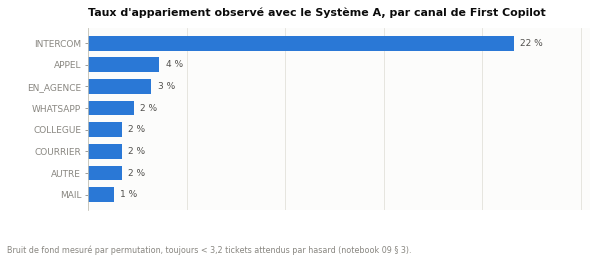

  -> resultats/tables/13_q7_recoupement_a_b.csv


  -> resultats/figures/13_q7_recoupement_a_b.png


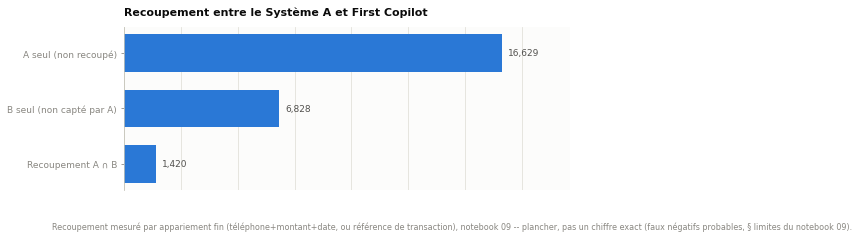

Canaux exclusifs à First Copilot (aucun équivalent dans A) : ['APPEL', 'AUTRE', 'COLLEGUE', 'COURRIER', 'EN_AGENCE', 'MAIL', 'WHATSAPP']
Sous-canaux digitaux exclusifs au Système A (channel)   : ['android', 'facebook', 'instagram', 'ios', 'messenger', 'whatsapp']
Dimension 'agence' : disponible uniquement dans B (100.0 % des tickets B dédupliqués rattachés à un groupe source).


In [14]:
fig, ax = plt.subplots(figsize=(9, max(3, 0.42 * len(taux_appariement))))
viz.barres_horizontales(
    taux_appariement.set_index("canal")["pct_observe"],
    "Taux d'appariement observé avec le Système A, par canal de First Copilot",
    unite=" %",
    ax=ax,
)
viz.annoter_source(fig, "Bruit de fond mesuré par permutation, toujours < 3,2 tickets attendus par hasard (notebook 09 § 3).")
viz.sauver(fig, "13_q7_taux_appariement_par_canal")
plt.show()

n_a_total = len(tickets_a)
n_recoupe = paires["ticket_id_a"].nunique()
n_a_seul = n_a_total - n_recoupe
n_b_seul = len(tickets_b)  # déjà dédupliqué : ce qui reste par construction n'est capté que par B

recoupement = pd.Series({
    "A seul (non recoupé)": n_a_seul,
    "Recoupement A ∩ B": n_recoupe,
    "B seul (non capté par A)": n_b_seul,
})
chargement.sauver_table(recoupement.rename("effectif").to_frame(), "13_q7_recoupement_a_b")

fig, ax = plt.subplots(figsize=(8, 3))
viz.barres_horizontales(recoupement, "Recoupement entre le Système A et First Copilot", ax=ax)
viz.annoter_source(
    fig,
    "Recoupement mesuré par appariement fin (téléphone+montant+date, ou référence de transaction), notebook 09 -- "
    "plancher, pas un chiffre exact (faux négatifs probables, § limites du notebook 09).",
)
viz.sauver(fig, "13_q7_recoupement_a_b")
plt.show()

canaux_b_only = sorted(set(tickets_b_brut["canal"].dropna().unique()) - {"INTERCOM"})
print(f"Canaux exclusifs à First Copilot (aucun équivalent dans A) : {canaux_b_only}")
print(f"Sous-canaux digitaux exclusifs au Système A (channel)   : {sorted(tickets_a['channel'].dropna().unique())}")
print(
    "Dimension 'agence' : disponible uniquement dans B "
    f"({tickets_b['source_group_id'].notna().mean() * 100:.1f} % des tickets B dédupliqués rattachés à un groupe source)."
)

## Q8 — Fiabilité de la reconstruction des sous-motifs (règles A vs annotation B)

Jeu de référence de fait (notebook 11) : sur les tickets appariés A↔B, le
sous-motif B (annotation humaine, indépendante du texte et des règles) sert
d'étalon pour juger `texte.classer()`. **Ce jeu est biaisé** — il ne couvre
que les tickets à la fois déposés digitalement et ressaisis manuellement
côté B, probablement les cas les plus clairs à qualifier (notebook 11 § 4).

In [15]:
jeu = paires[["ticket_id_a", "ticket_id_b", "methode"]].copy()
jeu["famille_a"] = jeu["ticket_id_a"].map(tickets_a.set_index("id")["famille"])
jeu["a_texte"] = jeu["ticket_id_a"].map(tickets_a.set_index("id")["a_texte"])
jeu = jeu.merge(sous_motifs_b, left_on="ticket_id_b", right_index=True, how="inner")
jeu = jeu.drop_duplicates(["ticket_id_a", "ticket_id_b"])
jeu = jeu[jeu["a_texte"] == True]
jeu = jeu.drop_duplicates("ticket_id_a")
print(f"Jeu de référence de fait (paires A↔B, sous-motif B + texte A exploitables) : {len(jeu):,} tickets")

confusion_brute = pd.crosstab(jeu["famille_a"], jeu["sous_motif"])
chargement.sauver_table(confusion_brute, "13_q8_confusion_brute")
confusion_brute

Jeu de référence de fait (paires A↔B, sous-motif B + texte A exploitables) : 962 tickets
  -> resultats/tables/13_q8_confusion_brute.csv


sous_motif,Autre,Bénéficiaire erroné,Fond non perçu,Opération Contestée,Opérations GAB,Opérations GAB AFB,Versement GAB,Échec Achat Air-Time,Échec Cash-In,Échec Cash-Out,Échec MAC Bank-to-Wallet,Échec Wallet-to-Other-Wallet,Échec Wallet-to-Wallet
famille_a,,,,,,,,,,,,,
acces_otp,0,1,0,0,0,0,0,0,36,0,0,0,0
carte,0,0,0,0,0,3,0,0,1,0,0,0,0
debit_injustifie,0,0,2,1,0,1,0,0,37,2,0,0,0
debit_non_credit,2,11,15,2,4,4,1,3,152,10,1,147,19
demande_info,0,0,0,0,0,0,0,0,1,0,0,1,0
erreur_client,0,210,3,0,0,0,0,0,11,1,0,5,0
non_classe,2,76,2,0,2,0,0,0,121,8,2,54,8


  -> resultats/figures/13_q8_confusion_heatmap.png


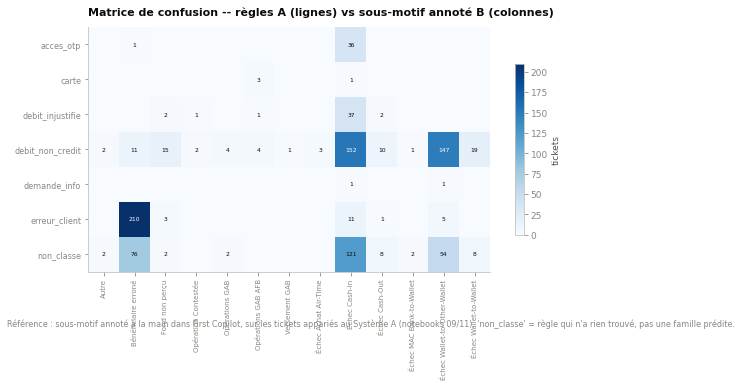

In [16]:
fig, ax = plt.subplots(figsize=(max(9, 0.5 * confusion_brute.shape[1]), max(4.5, 0.45 * confusion_brute.shape[0])))
matrice = confusion_brute.to_numpy()
im = ax.imshow(matrice, cmap="Blues", aspect="auto")
ax.set_xticks(range(confusion_brute.shape[1]))
ax.set_xticklabels(confusion_brute.columns, rotation=90, fontsize=7)
ax.set_yticks(range(confusion_brute.shape[0]))
ax.set_yticklabels(confusion_brute.index, fontsize=8)
seuil = matrice.max() * 0.6 if matrice.max() else 0
for i in range(confusion_brute.shape[0]):
    for j in range(confusion_brute.shape[1]):
        v = matrice[i, j]
        if v:
            ax.text(j, i, str(v), ha="center", va="center", fontsize=6,
                     color="white" if v > seuil else viz.ENCRE["primaire"])
ax.set_title("Matrice de confusion -- règles A (lignes) vs sous-motif annoté B (colonnes)")
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.7, label="tickets")
viz.annoter_source(
    fig,
    "Référence : sous-motif annoté à la main dans First Copilot, sur les tickets appariés au Système A (notebooks 09/11). "
    "'non_classe' = règle qui n'a rien trouvé, pas une famille prédite.",
)
viz.sauver(fig, "13_q8_confusion_heatmap")
plt.show()

In [17]:
# Mapping écrit après lecture de la matrice brute (notebook 11 § 3) -- documenté et
# contestable, pas une vérité déjà validée par le métier.
MAPPING_TAXONOMIE = {
    "erreur_client": {"Bénéficiaire erroné"},
    "debit_non_credit": {
        "Échec Cash-In", "Échec Cash-Out", "Échec Wallet-to-Wallet",
        "Échec Wallet-to-Other-Wallet", "Fond non perçu",
        "Échec Achat Air-Time", "Échec MAC Bank-to-Wallet", "Échec MAC Wallet-to-Bank",
    },
}

lignes = []
for famille, sous_motifs_attendus in MAPPING_TAXONOMIE.items():
    zone_b = jeu["sous_motif"].isin(sous_motifs_attendus)
    predit_a = jeu["famille_a"] == famille

    vp = int((zone_b & predit_a).sum())
    fp = int((~zone_b & predit_a).sum())
    fn = int((zone_b & ~predit_a).sum())

    precision = vp / (vp + fp) if (vp + fp) else float("nan")
    rappel = vp / (vp + fn) if (vp + fn) else float("nan")
    f1 = 2 * precision * rappel / (precision + rappel) if precision and rappel else float("nan")

    lignes.append({
        "famille": famille, "n_reference_b": int(zone_b.sum()),
        "vrai_positif": vp, "faux_positif": fp, "faux_negatif": fn,
        "precision": round(precision, 3), "rappel": round(rappel, 3), "f1": round(f1, 3),
    })

resultat_q8 = pd.DataFrame(lignes)
chargement.sauver_table(resultat_q8, "13_q8_precision_rappel_f1", index=False)
resultat_q8

  -> resultats/tables/13_q8_precision_rappel_f1.csv


,famille,n_reference_b,vrai_positif,faux_positif,faux_negatif,precision,rappel,f1
0,erreur_client,298,210,20,88,0.913,0.705,0.795
1,debit_non_credit,642,347,24,295,0.935,0.540,0.685


  -> resultats/figures/13_q8_precision_rappel_f1.png


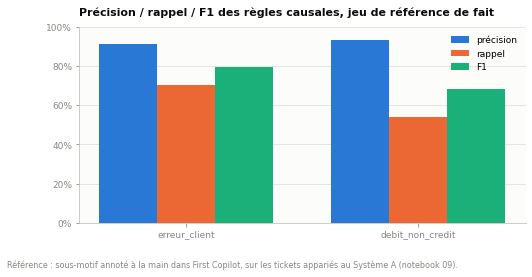

In [18]:
fig, ax = plt.subplots(figsize=(8, 3.6))
x = range(len(resultat_q8))
largeur = 0.25
ax.bar([i - largeur for i in x], resultat_q8["precision"], width=largeur, label="précision", color=viz.SERIES[0])
ax.bar(list(x), resultat_q8["rappel"], width=largeur, label="rappel", color=viz.SERIES[1])
ax.bar([i + largeur for i in x], resultat_q8["f1"], width=largeur, label="F1", color=viz.SERIES[2])
ax.set_xticks(list(x))
ax.set_xticklabels(resultat_q8["famille"])
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1, decimals=0))
ax.set_title("Précision / rappel / F1 des règles causales, jeu de référence de fait")
ax.legend(frameon=False, fontsize=9)
ax.grid(axis="x", visible=False)
viz.annoter_source(fig, "Référence : sous-motif annoté à la main dans First Copilot, sur les tickets appariés au Système A (notebook 09).")
viz.sauver(fig, "13_q8_precision_rappel_f1")
plt.show()

**Lecture** — précision haute (~0,93) sur les deux familles évaluables :
quand les règles affirment `erreur_client` ou `debit_non_credit`, elles ont
raison la plupart du temps. Rappel nettement plus bas (~0,49-0,60) : les
règles manquent 4 à 5 tickets sur 10 que l'agent qualifie pourtant sans
ambiguïté dans le même domaine. **La reconstruction automatique n'est donc
pas fiable pour un comptage exhaustif** (elle sous-compte), mais elle l'est
pour hiérarchiser les familles entre elles (peu de faux positifs) — c'est
l'argument chiffré en faveur d'une classification apprise (notebook 11 § 4,
et la discussion de ce chantier sur pourquoi une méthode par règles a été
choisie en premier).

## Q9 — Reproductibilité sur un prochain export

Ce qui est déjà centralisé dans `config.py` (donc reproductible sans
modifier un notebook) : les chemins de recherche des fichiers, les seuils
(`LONGUEUR_TEXTE_MIN`, `SEUIL_COUVERTURE_JOURNALIERE`, `FENETRE_REDEPOT_JOURS`,
`FENETRE_APPARIEMENT_JOURS`), les plafonds de montant plausible, et les dates
de coupure (`DEBUT_PERIODE_OPERATIONNELLE`, `DATE_RUPTURE_COLLECTE`). La
cellule ci-dessous est un **test exécutable** : la relancer sur un nouvel
export dit immédiatement si les fichiers attendus sont trouvés, avant
d'aller plus loin.

In [19]:
print("Système A :")
print(f"  export brut trouvé          : {config.chemin_donnees()}")
print(f"  export conversations trouvé : {config.chemin_conversations()}")
print()
print("First Copilot -- fichiers attendus (config.FICHIERS_SYSTEME_B) :")
for nom in config.FICHIERS_SYSTEME_B:
    chemin = config.chemin_systeme_b(nom)
    statut = "OK" if chemin else "MANQUANT"
    suffixe = f" -> {chemin}" if chemin else ""
    print(f"  [{statut}] {nom}{suffixe}")

Système A :
  export brut trouvé          : /home/gauss/Bureau/Afriland/analyse des reclamation clients/dataset/SRC_Intercom_Reclamation_202607201846.csv
  export conversations trouvé : /home/gauss/Bureau/Afriland/analyse des reclamation clients/dataset/Interc/conversations_.xlsx

First Copilot -- fichiers attendus (config.FICHIERS_SYSTEME_B) :
  [OK] tickets_first.xlsx -> /home/gauss/Bureau/Afriland/analyse des reclamation clients/dataset/Nouveau dossier 1/Nouveau dossier/tickets_first.xlsx
  [OK] categories.xlsx -> /home/gauss/Bureau/Afriland/analyse des reclamation clients/dataset/Nouveau dossier 1/Nouveau dossier/categories.xlsx
  [OK] groups.xlsx -> /home/gauss/Bureau/Afriland/analyse des reclamation clients/dataset/Nouveau dossier 1/Nouveau dossier/groups.xlsx
  [OK] users.xlsx -> /home/gauss/Bureau/Afriland/analyse des reclamation clients/dataset/Nouveau dossier 1/Nouveau dossier/users.xlsx
  [OK] ticket_assigned_users.xlsx -> /home/gauss/Bureau/Afriland/analyse des reclamation 

**Ce qui ne se reproduit pas tout seul, et doit être revérifié à la main
sur chaque nouvel export** :

1. **`config.DATE_RUPTURE_COLLECTE` / `config.MOIS_COLLECTE_DEGRADEE`**
   décrivent un incident précis (13/03/2026). Un nouvel export peut porter
   un autre incident, à une autre date, ou aucun — le test de complétude par
   jour (`chargement.taux_completude`, notebook 02 § 3) doit être rejoué,
   pas seulement les dates recopiées.
2. **`texte.FAMILLES`** (règles causales) et **`MAPPING_TAXONOMIE`** (Q8,
   notebook 11 § 3) sont écrits à la main sur le vocabulaire observé à ce
   jour. Si First Copilot ajoute ou renomme un sous-motif, le mapping doit
   être relu sur la nouvelle matrice de confusion, pas réappliqué tel quel.
3. **`config.AUDIT_MANUEL`** (notebook 04) est un décompte figé sur 20
   textes tirés avec la graine 3 -- un nouvel export change le reliquat non
   classé et rend cet audit obsolète ; il doit être refait (ou remplacé par
   la validation croisée de Q8, plus robuste, si le nouvel export permet
   encore l'appariement A↔B).
4. **Les clés d'appariement A↔B** (`consolidation.cles_a`/`cles_b`) supposent
   les mêmes noms de colonnes des deux côtés (`ticket_attributes_Numero_tel_client`,
   `contacts_contacts`, les 3 dropdowns `CHAMPS_SOUS_MOTIF`...) -- un export
   qui renomme un champ casse silencieusement l'appariement plutôt que de
   lever une erreur claire ; à vérifier explicitement, pas supposé.
5. **Le nombre de tickets et tous les pourcentages de ce notebook** doivent
   être recalculés, jamais recopiés d'un export à l'autre -- ce notebook
   entier est fait pour être rejoué intégralement (`Kernel -> Restart & Run
   All`), pas mis à jour cellule par cellule.

## Limites qui s'appliquent à l'ensemble de ce notebook

Rappel, valable pour toutes les réponses ci-dessus (détail dans les
notebooks sources cités à chaque section) :

- **Aucun journal de transactions** : le dénominateur reste absent des deux
  systèmes, le taux d'incident par transaction reste hors de portée
  (protocole § 6.1).
- **Les montants (Q4) sont des ordres de grandeur**, jamais des chiffres
  officiels — champ non validé par le métier. Les **totaux** se cumulent
  entre systèmes, les **médianes** non : une médiane de médianes n'a pas de
  sens, d'où deux colonnes distinctes.
- **Le dédoublonnage (Q1, Q7) sous-estime probablement les vrais doublons**
  — c'est un plancher, pas un chiffre définitif (notebook 09 § 6). Toutes
  les sommes consolidées A + B (Q2, Q3, Q4) en héritent : elles peuvent
  contenir un **résidu de double comptage**, en particulier sur la ligne
  INTERCOM de Q3, la plus exposée par construction.
- **La correspondance de taxonomie (Q1, Q8) ne couvre que 2 des 6 familles
  causales de A** — les 4 autres n'ont pas de pont validé vers First Copilot.
  C'est la raison pour laquelle Q1 est la seule question où les deux
  systèmes sont présentés ensemble sans jamais être additionnés.
- **Les périmètres des deux systèmes ne sont pas identiques** : A porte
  l'intégralité de sa période opérationnelle, B est restreint à ce qui n'a
  pas été retrouvé dans A. Une catégorie absente d'un système (`AUTRE`,
  `BENEFICIAIRE ERRONE`) signale une nomenclature propre à l'outil, pas un
  volume nul.